In [1]:
import psycopg2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Подключение к базе данных

In [ ]:
DB_CONFIG = {
    "host": "postgres",
    "port": 5432,
    "dbname": "creditdb",
    "user": "postgres",
    "password": "postgres",
}

conn = psycopg2.connect(**DB_CONFIG)


## 2. Загрузка данных из БД

Выполняем JOIN по всем связанным таблицам и загружаем выборку.

In [ ]:
QUERY = """
SELECT
    f.film_id,
    f.score_rating,
    fd.country,
    fd.release_year,
    fd.duration_minutes,
    g.name AS genre,
    a.actor_id
FROM films f
JOIN film_details fd ON f.film_id = fd.film_id
JOIN film_genre fg ON f.film_id = fg.film_id
JOIN genres g ON fg.genre_id = g.genre_id
JOIN film_actor fa ON f.film_id = fa.film_id
JOIN actors a ON fa.actor_id = a.actor_id
"""

df = pd.read_sql(QUERY, conn)
conn.close()

## 3. Просмотр сырых данных

In [4]:
print(f"Уникальных фильмов: {df['film_id'].nunique():,}")
print(f"Уникальных актёров: {df['actor_id'].nunique():,}")
print(f"Уникальных жанров: {df['genre'].nunique()}")
print(f"Уникальных стран: {df['country'].nunique()}")
print(f"Диапазон release_year: {int(df['release_year'].min())} – {int(df['release_year'].max())}")
print(f"Длительность (мин): {int(df['duration_minutes'].min())} – {int(df['duration_minutes'].max())}")

Уникальных фильмов: 1,000,000
Уникальных актёров: 4,999
Уникальных жанров: 10
Уникальных стран: 12
Диапазон release_year: 1980 – 2025
Длительность (мин): 75 – 210


## 4. Подготовка признаков

In [5]:
agg = (
    df.groupby("film_id")
    .agg(
        score_rating = ("score_rating", "first"),
        country = ("country", "first"),
        release_year = ("release_year", "first"),
        duration_minutes = ("duration_minutes", "first"),
        genre = ("genre", lambda x: x.mode()[0]),
        top_actor = ("actor_id", lambda x: x.mode()[0]),
    )
    .reset_index()
)


## 5. Целевая переменная

Разбиваем `score_rating` на 3 класса:

| Класс | Диапазон | Метка |
|-------|----------|-------|
| 0     | 0 – 3.33 | low   |
| 1     | 3.33 – 6.67 | mid |
| 2     | 6.67 – 10 | high |

,Класс,Количество фильмов,"Доля, %"
0,low (0–3.33),9862,0.99
1,mid (3.33–6.67),698719,69.87
2,high (6.67–10),291419,29.14


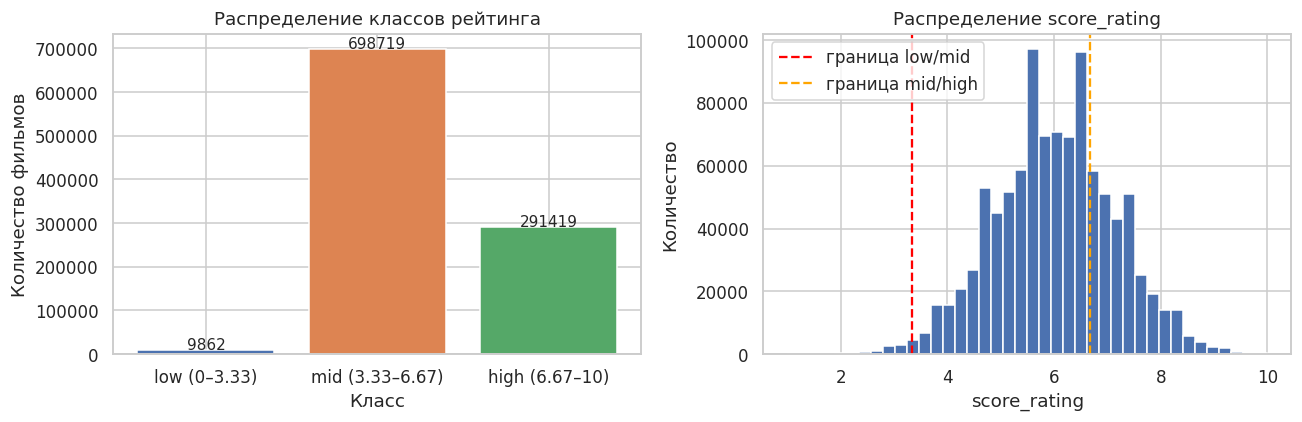

In [6]:
agg["rating_class"] = pd.cut(
    agg["score_rating"].astype(float),
    bins=[0, 3.33, 6.67, 10],
    labels=[0, 1, 2],
    include_lowest=True,
).astype(int)

class_names = ["low (0–3.33)", "mid (3.33–6.67)", "high (6.67–10)"]
counts = agg["rating_class"].value_counts().sort_index()

dist_df = pd.DataFrame({
    "Класс": class_names,
    "Количество фильмов": counts.values,
    "Доля, %": (counts.values / counts.sum() * 100).round(2),
})
display(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, counts.values, color=["#4C72B0","#DD8452","#55A868"], edgecolor="white")
axes[0].set_title("Распределение классов рейтинга")
axes[0].set_ylabel("Количество фильмов")
axes[0].set_xlabel("Класс")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=10)

axes[1].hist(agg["score_rating"].astype(float), bins=40, color="#4C72B0", edgecolor="white")
axes[1].axvline(3.33, color="red", linestyle="--", label="граница low/mid")
axes[1].axvline(6.67, color="orange", linestyle="--", label="граница mid/high")
axes[1].set_title("Распределение score_rating")
axes[1].set_xlabel("score_rating")
axes[1].set_ylabel("Количество")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Кодирование признаков

In [7]:
le_country = LabelEncoder()
le_genre = LabelEncoder()
le_actor = LabelEncoder()

agg["country_enc"] = le_country.fit_transform(agg["country"].fillna("Unknown"))
agg["genre_enc"] = le_genre.fit_transform(agg["genre"])
agg["actor_enc"] = le_actor.fit_transform(agg["top_actor"].astype(str))

enc_preview = agg[
    ["country","country_enc","genre","genre_enc","release_year","duration_minutes"]
].drop_duplicates("genre_enc").head(10)
display(enc_preview.reset_index(drop=True))

X = agg[["genre_enc", "actor_enc", "country_enc", "release_year", "duration_minutes"]].values
y = agg["rating_class"].values

,country,country_enc,genre,genre_enc,release_year,duration_minutes
0,UK,10,Crime,4,2005,100
1,Spain,8,Thriller,9,2012,112
2,India,4,Adventure,1,2016,112
3,Japan,6,Drama,5,2001,107
4,Japan,6,Horror,6,2019,108
5,Australia,0,Animation,2,1980,150
6,Italy,5,Romance,7,1995,127
7,Italy,5,Sci-Fi,8,2006,126
8,Spain,8,Action,0,2020,103
9,Spain,8,Comedy,3,2024,75


## 7. Разделение на train / test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

split_df = pd.DataFrame({
    "Выборка": ["Train", "Test", "Всего"],
    "Размер": [len(X_train), len(X_test), len(X_train)+len(X_test)],
    "Доля, %": [80, 20, 100],
})
display(split_df)

,Выборка,Размер,"Доля, %"
0,Train,800000,80
1,Test,200000,20
2,Всего,1000000,100


## 8. Поиск оптимальных гиперпараметров


In [9]:
n_estimators_range = [10, 25, 50, 100, 150, 200]
scores_n = []

for n in n_estimators_range:
    clf = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    cv  = cross_val_score(clf, X_train, y_train, cv=3, scoring="accuracy")
    scores_n.append(cv.mean())
    print(f"  n_estimators={n:3d}, CV accuracy = {cv.mean():.4f}")

best_n = n_estimators_range[int(np.argmax(scores_n))]
print(f"\n Лучшее n_estimators = {best_n}")

  n_estimators= 10, CV accuracy = 0.7151
  n_estimators= 25, CV accuracy = 0.7154
  n_estimators= 50, CV accuracy = 0.7153
  n_estimators=100, CV accuracy = 0.7156
  n_estimators=150, CV accuracy = 0.7155
  n_estimators=200, CV accuracy = 0.7155

 Лучшее n_estimators = 100


In [10]:
max_depth_range = [3, 5, 7, 10, 15, 20, None]
depth_labels = [str(d) if d else "None" for d in max_depth_range]
scores_d = []

for d in max_depth_range:
    clf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42, n_jobs=-1)
    cv = cross_val_score(clf, X_train, y_train, cv=3, scoring="accuracy")
    scores_d.append(cv.mean())
    print(f"  max_depth={str(d):4s}, CV accuracy = {cv.mean():.4f}")

best_d = max_depth_range[int(np.argmax(scores_d))]
print(f"\nЛучшее max_depth = {best_d}")

  max_depth=3   , CV accuracy = 0.6999
  max_depth=5   , CV accuracy = 0.7065
  max_depth=7   , CV accuracy = 0.7129
  max_depth=10  , CV accuracy = 0.7156
  max_depth=15  , CV accuracy = 0.7144
  max_depth=20  , CV accuracy = 0.7061
  max_depth=None, CV accuracy = 0.6887

Лучшее max_depth = 10


### Графики зависимости качества от гиперпараметров

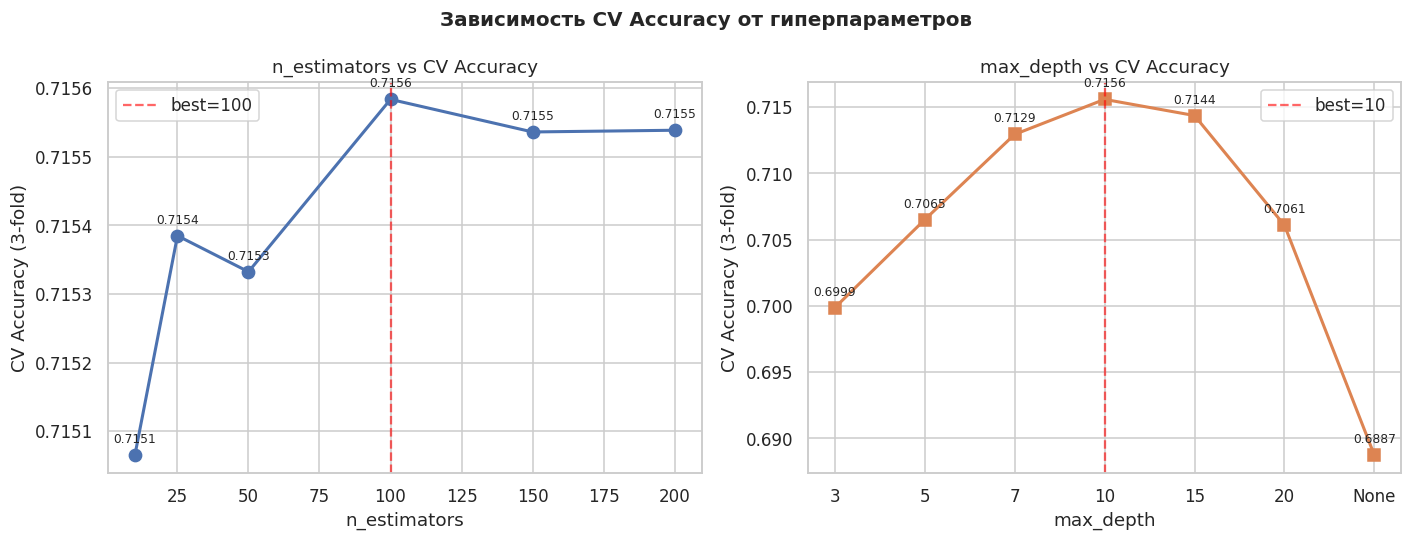

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(n_estimators_range, scores_n, marker="o", color="#4C72B0", linewidth=2, markersize=8)
axes[0].axvline(best_n, color="red", linestyle="--", alpha=0.6, label=f"best={best_n}")
axes[0].set_title("n_estimators vs CV Accuracy")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("CV Accuracy (3-fold)")
axes[0].legend()
axes[0].grid(True)
for x, y_ in zip(n_estimators_range, scores_n):
    axes[0].annotate(f"{y_:.4f}", (x, y_), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

best_d_label = str(best_d) if best_d else "None"
axes[1].plot(depth_labels, scores_d, marker="s", color="#DD8452", linewidth=2, markersize=8)
axes[1].axvline(depth_labels.index(best_d_label), color="red", linestyle="--", alpha=0.6, label=f"best={best_d_label}")
axes[1].set_title("max_depth vs CV Accuracy")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("CV Accuracy (3-fold)")
axes[1].legend()
axes[1].grid(True)
for i, y_ in enumerate(scores_d):
    axes[1].annotate(f"{y_:.4f}", (i, y_), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.suptitle("Зависимость CV Accuracy от гиперпараметров", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Обучение финальной модели

In [12]:
print(f"Обучаем RandomForest: n_estimators={best_n}, max_depth={best_d}")

clf_best = RandomForestClassifier(
    n_estimators = best_n,
    max_depth = best_d,
    random_state = 42,
    n_jobs = -1,
)
clf_best.fit(X_train, y_train)

Обучаем RandomForest: n_estimators=100, max_depth=10


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 10. Процесс обучения RandomForest

In [13]:

staged_n   = list(range(1, best_n + 1, max(1, best_n // 30)))
staged_acc = []

for n in staged_n:
    clf_s = RandomForestClassifier(
        n_estimators=n, max_depth=best_d,
        random_state=42, n_jobs=-1, warm_start=False
    )
    clf_s.fit(X_train, y_train)
    staged_acc.append(accuracy_score(y_test, clf_s.predict(X_test)))


## 11. Оценка модели на тестовой выборке

In [14]:
y_pred = clf_best.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.7150


In [15]:

report_dict = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T.round(4)
display(report_df)

,precision,recall,f1-score,support
low (0–3.33),0.0000,0.0000,0.0000,1972.000
mid (3.33–6.67),0.7297,0.9404,0.8218,139744.000
high (6.67–10),0.5815,0.1986,0.2961,58284.000
accuracy,0.7150,0.7150,0.7150,0.715
macro avg,0.4371,0.3797,0.3726,200000.000
weighted avg,0.6793,0.7150,0.6605,200000.000


## 12. Итоговые результаты

In [16]:
summary = pd.DataFrame({
    "Параметр": [
        "Всего фильмов",
        "Train size",
        "Test size",
        "Лучшее n_estimators",
        "Лучшее max_depth",
        "Test Accuracy",
    ],
    "Значение": [
        f"{len(agg):,}",
        f"{len(X_train):,} (80%)",
        f"{len(X_test):,} (20%)",
        str(best_n),
        str(best_d),
        f"{acc:.4f}",
    ],
})
display(summary)

,Параметр,Значение
0,Всего фильмов,"1,000,000"
1,Train size,"800,000 (80%)"
2,Test size,"200,000 (20%)"
3,Лучшее n_estimators,100
4,Лучшее max_depth,10
5,Test Accuracy,0.7150
